# Qiyas Crop Yield Hackathon — B: Data Analysis Report

All 14 analysis tasks (B1.1–B4.3). Uses the cleaned, joined master table from Deliverable A.
Each task ends with a short interpretation.

**This version uses charts instead of tables.**

## 0. Setup & Load Master Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = Path("../data/processed")
RAW_DIR = Path("../data/raw")

# Prefer master_train (from A). Fall back to train_weather_integrated if needed.
master_path = PROCESSED_DIR / "master_train.csv"
if not master_path.exists():
    master_path = PROCESSED_DIR / "train_weather_integrated.csv"

data = pd.read_csv(master_path)
print("Loaded:", master_path)
print("Shape:", data.shape)
print("Columns:", data.columns.tolist()[:20], "...")

# Price may have been dropped from master tables (Rule: not a model feature).
# Reload prices and re-attach for analysis only.
prices = pd.read_csv(RAW_DIR / "market_prices.csv")
# light standardize so join keys match
for df in [data, prices]:
    for col in ["region", "crop_type"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
region_map = {"oro":"oromia","amh":"amhara","snnp":"snnpr","som":"somali","tig":"tigray"}
crop_map = {"tef":"teff"}
if "region" in prices.columns:
    prices["region"] = prices["region"].replace(region_map)
if "crop_type" in prices.columns:
    prices["crop_type"] = prices["crop_type"].replace(crop_map)

if "price_birr_per_quintal" not in data.columns:
    data = data.merge(
        prices.rename(columns={"year": "survey_year"}),
        on=["region", "crop_type", "survey_year"],
        how="left"
    )
    # fill unmatched with overall median for analysis continuity
    data["price_birr_per_quintal"] = data["price_birr_per_quintal"].fillna(
        data["price_birr_per_quintal"].median()
    )

print("Price available:", "price_birr_per_quintal" in data.columns)
print("Rows:", len(data))

Task was destroyed but it is pending!
task: <Task pending name='Task-147' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\hp\anaconda3\envs\tf-env\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-148' coro=<Kernel.shell_main() running at C:\Users\hp\anaconda3\envs\tf-env\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\hp\anaconda3\envs\tf-env\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-148' coro=<Kernel.shell_main() running at C:\Users\hp\anaconda3\envs\tf-env\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-246' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\hp\anaconda3\envs\tf-env\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Ta

Loaded: ..\data\processed\master_train.csv
Shape: (15090, 33)
Columns: ['plot_id', 'region', 'crop_type', 'survey_year', 'planting_month', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km', 'planting_month_num', 'season_temp_mean', 'season_temp_min', 'season_temp_max', 'season_rain_total', 'season_rain_mean'] ...
Price available: True
Rows: 15090


## B1 — Value & Prices

### B1.1 Revenue per hectare by crop
Estimated revenue per hectare = `yield_tons_per_ha × 10 × price_birr_per_quintal`.

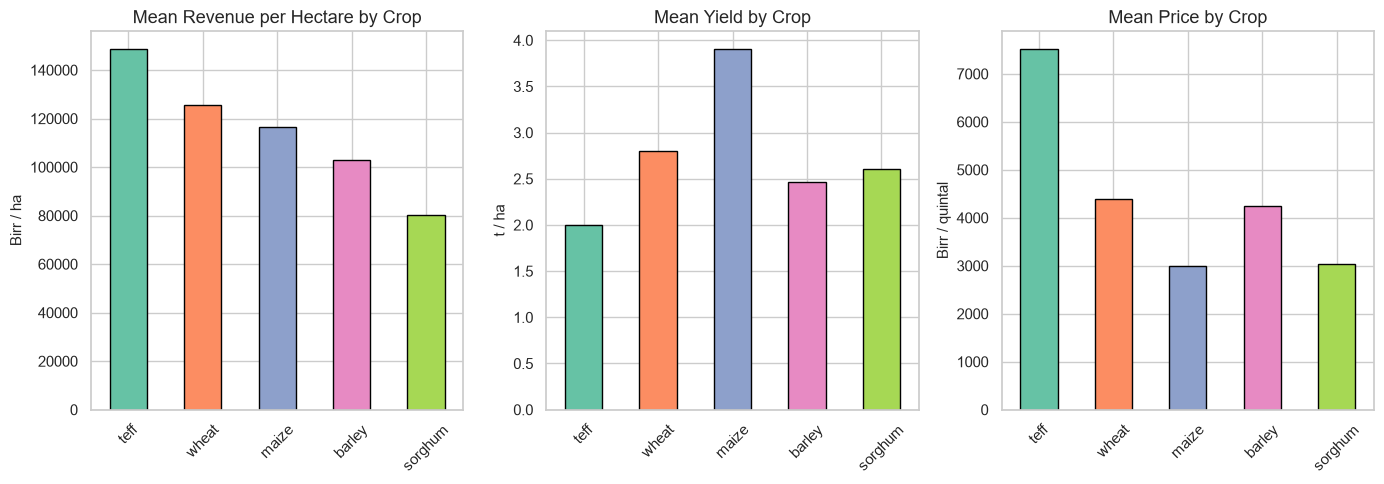

Highest revenue/ha: teff
Highest yield:      maize
Interpretation: teff earns the most per hectare. It is NOT the same as the highest-yield crop (maize); price differences change the ranking.


In [17]:
# B1.1 Revenue per hectare by crop
data["revenue_per_ha"] = (
    data["yield_tons_per_ha"] * 10 * data["price_birr_per_quintal"]
)

rev_by_crop = (
    data.groupby("crop_type")
    .agg(
        mean_yield=("yield_tons_per_ha", "mean"),
        mean_price=("price_birr_per_quintal", "mean"),
        mean_revenue_per_ha=("revenue_per_ha", "mean"),
        plots=("plot_id", "count")
    )
    .sort_values("mean_revenue_per_ha", ascending=False)
    .round(2)
)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Revenue bar
colors = sns.color_palette("Set2", len(rev_by_crop))
rev_by_crop["mean_revenue_per_ha"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="black")
axes[0].set_title("Mean Revenue per Hectare by Crop")
axes[0].set_ylabel("Birr / ha")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Yield bar
rev_by_crop["mean_yield"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="black")
axes[1].set_title("Mean Yield by Crop")
axes[1].set_ylabel("t / ha")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

# Price bar
rev_by_crop["mean_price"].plot(kind="bar", ax=axes[2], color=colors, edgecolor="black")
axes[2].set_title("Mean Price by Crop")
axes[2].set_ylabel("Birr / quintal")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

top_rev_crop = rev_by_crop["mean_revenue_per_ha"].idxmax()
top_yield_crop = rev_by_crop["mean_yield"].idxmax()
print(f"Highest revenue/ha: {top_rev_crop}")
print(f"Highest yield:      {top_yield_crop}")
print(
    f"Interpretation: {top_rev_crop} earns the most per hectare. "
    f"{'It is the same crop that has the highest yield.' if top_rev_crop == top_yield_crop else f'It is NOT the same as the highest-yield crop ({top_yield_crop}); price differences change the ranking.'}"
)

### B1.2 Price trend (2021–2024)

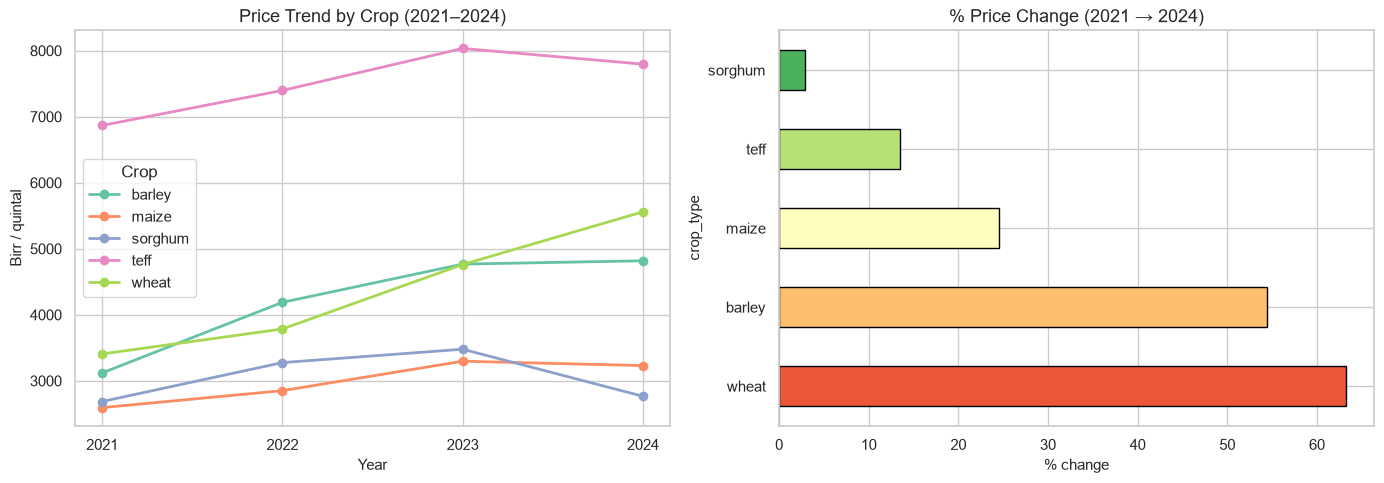

Fastest price growth: wheat (63.2%)
Slowest price growth: sorghum (2.9%)
Gap (pp): 60.3
Interpretation: wheat grew fastest. The gap of 60.3 percentage points is large enough to matter for crop-choice decisions.


In [18]:
# B1.2 Price trend by crop
price_year = (
    data.groupby(["crop_type", "survey_year"])["price_birr_per_quintal"]
    .mean()
    .unstack("survey_year")
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart of price trends
for crop in price_year.index:
    axes[0].plot(price_year.columns, price_year.loc[crop], marker="o", linewidth=2, label=crop)
axes[0].set_title("Price Trend by Crop (2021–2024)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Birr / quintal")
axes[0].legend(title="Crop")
axes[0].set_xticks(price_year.columns)

# Absolute and % change 2021 → 2024
years = sorted([c for c in price_year.columns if pd.notna(c)])
y0, y1 = years[0], years[-1]
price_change = pd.DataFrame({
    "price_" + str(y0): price_year[y0],
    "price_" + str(y1): price_year[y1],
})
price_change["abs_change"] = price_change.iloc[:, 1] - price_change.iloc[:, 0]
price_change["pct_change"] = (price_change["abs_change"] / price_change.iloc[:, 0] * 100).round(1)
price_change = price_change.sort_values("pct_change", ascending=False)

price_change["pct_change"].plot(kind="barh", ax=axes[1], color=sns.color_palette("RdYlGn", len(price_change)), edgecolor="black")
axes[1].set_title(f"% Price Change ({y0} → {y1})")
axes[1].set_xlabel("% change")
axes[1].axvline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

fastest = price_change["pct_change"].idxmax()
slowest = price_change["pct_change"].idxmin()
gap = price_change.loc[fastest, "pct_change"] - price_change.loc[slowest, "pct_change"]
print(f"Fastest price growth: {fastest} ({price_change.loc[fastest, 'pct_change']}%)")
print(f"Slowest price growth: {slowest} ({price_change.loc[slowest, 'pct_change']}%)")
print(f"Gap (pp): {gap:.1f}")
print(
    f"Interpretation: {fastest} grew fastest. "
    f"The gap of {gap:.1f} percentage points "
    f"{'is large enough to matter for crop-choice decisions.' if abs(gap) >= 10 else 'is modest and may not dominate other agronomic factors.'}"
)

## B2 — Category Breakdowns

### B2.1 Yield by region

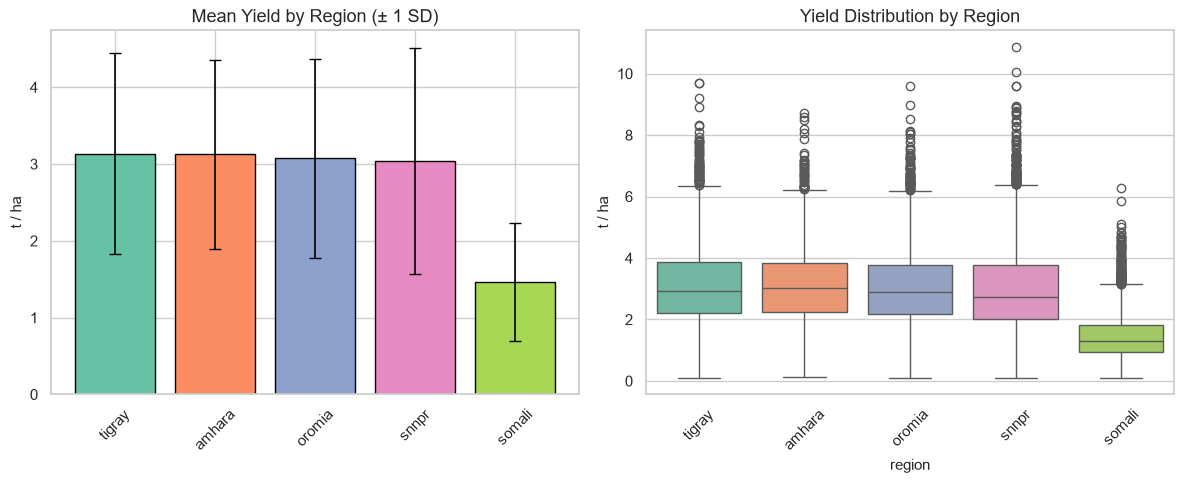

Highest average yield: tigray
Most variable:         snnpr
Interpretation: tigray has the highest average yield. snnpr shows the greatest within-region variability.


In [19]:
# B2.1 Yield by region
yield_region = (
    data.groupby("region")["yield_tons_per_ha"]
    .agg(mean="mean", median="median", std="std", plots="count")
    .sort_values("mean", ascending=False)
    .round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mean yield bars with error bars (std)
axes[0].bar(yield_region.index, yield_region["mean"], yerr=yield_region["std"],
            color=sns.color_palette("Set2", len(yield_region)), edgecolor="black",
            capsize=4, error_kw={"linewidth": 1.2})
axes[0].set_title("Mean Yield by Region (± 1 SD)")
axes[0].set_ylabel("t / ha")
axes[0].tick_params(axis="x", rotation=45)

# Box plot for distribution
order = yield_region.index.tolist()
sns.boxplot(data=data, x="region", y="yield_tons_per_ha", order=order, ax=axes[1], palette="Set2")
axes[1].set_title("Yield Distribution by Region")
axes[1].set_ylabel("t / ha")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

highest_region = yield_region["mean"].idxmax()
most_variable = yield_region["std"].idxmax()
print(f"Highest average yield: {highest_region}")
print(f"Most variable:         {most_variable}")
print(
    f"Interpretation: {highest_region} has the highest average yield. "
    f"{most_variable} shows the greatest within-region variability."
)

### B2.2 Yield by crop type

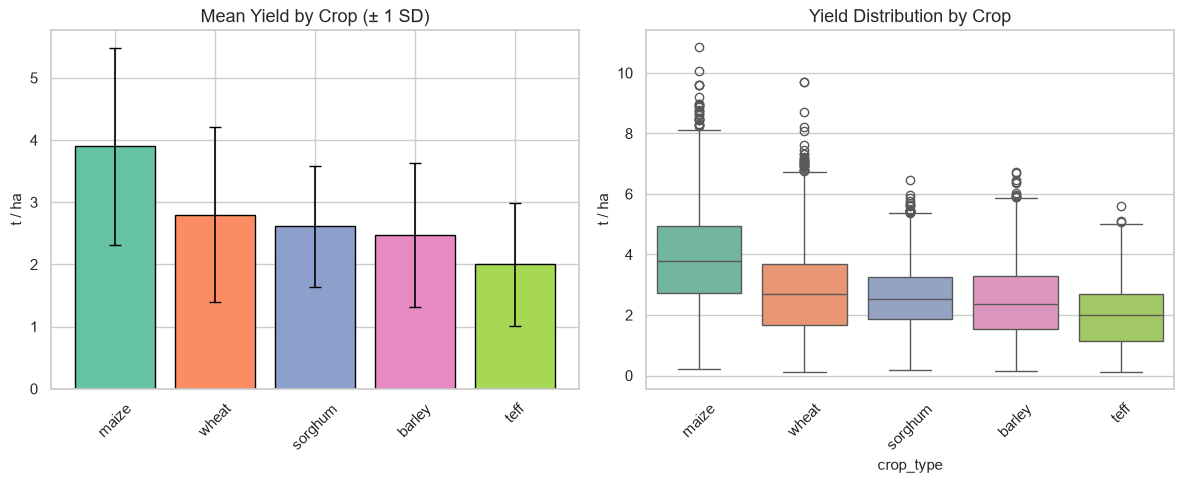

Highest-yielding crop: maize
Lowest-yielding crop:  teff
Interpretation: Rankings should broadly match biological yield potential (e.g. maize typically higher than teff/barley). Any surprise ranking warrants a check of regional mix and input levels.


In [20]:
# B2.2 Yield by crop
yield_crop = (
    data.groupby("crop_type")["yield_tons_per_ha"]
    .agg(mean="mean", median="median", std="std", plots="count")
    .sort_values("mean", ascending=False)
    .round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(yield_crop.index, yield_crop["mean"], yerr=yield_crop["std"],
            color=sns.color_palette("Set2", len(yield_crop)), edgecolor="black",
            capsize=4, error_kw={"linewidth": 1.2})
axes[0].set_title("Mean Yield by Crop (± 1 SD)")
axes[0].set_ylabel("t / ha")
axes[0].tick_params(axis="x", rotation=45)

order = yield_crop.index.tolist()
sns.boxplot(data=data, x="crop_type", y="yield_tons_per_ha", order=order, ax=axes[1], palette="Set2")
axes[1].set_title("Yield Distribution by Crop")
axes[1].set_ylabel("t / ha")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Highest-yielding crop: {yield_crop['mean'].idxmax()}")
print(f"Lowest-yielding crop:  {yield_crop['mean'].idxmin()}")
print(
    "Interpretation: Rankings should broadly match biological yield potential "
    "(e.g. maize typically higher than teff/barley). Any surprise ranking warrants a check of regional mix and input levels."
)

### B2.3 Region × crop pivot

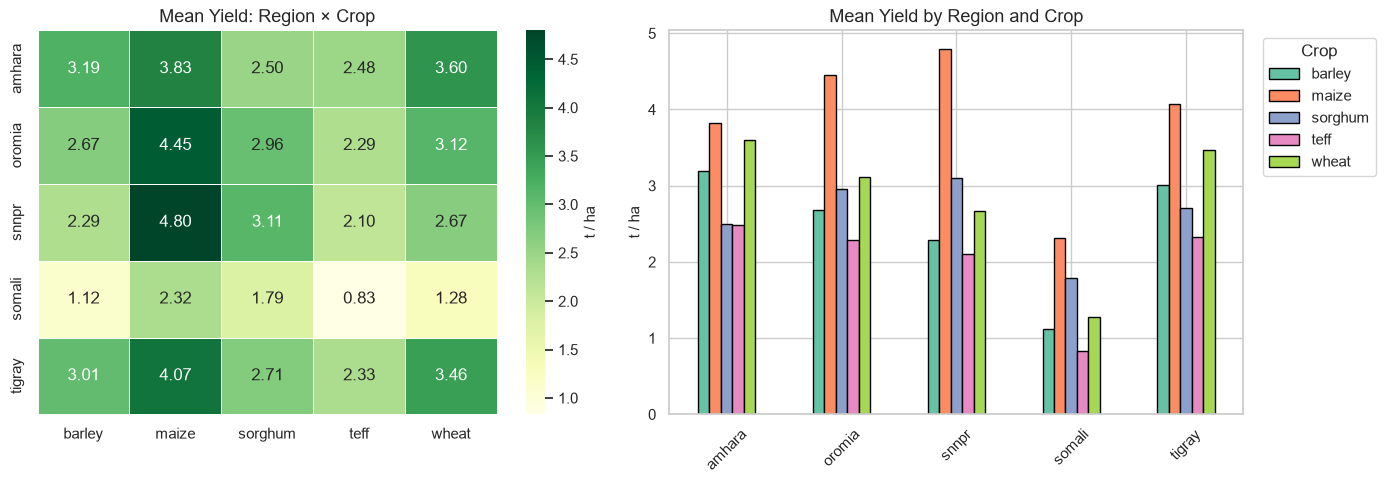

Best combination:  snnpr × maize  → 4.797 t/ha
Worst combination: somali × teff → 0.831 t/ha
Interpretation: Best/worst cells often reflect agro-ecological fit (e.g. highland barley/wheat vs lowland sorghum) and regional input intensity.


In [21]:
# B2.3 Region × crop mean yield
region_crop = pd.pivot_table(
    data, index="region", columns="crop_type",
    values="yield_tons_per_ha", aggfunc="mean"
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(region_crop, annot=True, fmt=".2f", cmap="YlGn", ax=axes[0],
            linewidths=0.5, cbar_kws={"label": "t / ha"})
axes[0].set_title("Mean Yield: Region × Crop")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# Grouped bar chart
region_crop.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Mean Yield by Region and Crop")
axes[1].set_ylabel("t / ha")
axes[1].set_xlabel("")
axes[1].legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

stacked = region_crop.stack().dropna()
best = stacked.idxmax()
worst = stacked.idxmin()
print(f"Best combination:  {best[0]} × {best[1]}  → {stacked.max():.3f} t/ha")
print(f"Worst combination: {worst[0]} × {worst[1]} → {stacked.min():.3f} t/ha")
print(
    "Interpretation: Best/worst cells often reflect agro-ecological fit "
    "(e.g. highland barley/wheat vs lowland sorghum) and regional input intensity."
)

### B2.4 Improved seed, by crop

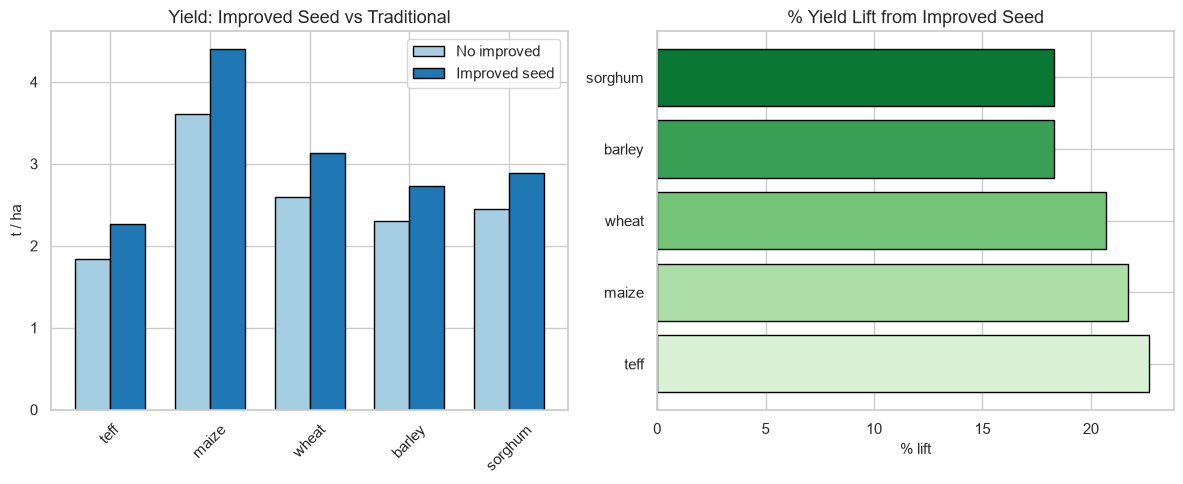

Crop that benefits most from improved seed: teff (22.7%)
Interpretation: % lift ranges from 18.3% to 22.7%. Lifts are fairly consistent across crops.


In [22]:
# B2.4 Improved seed yield gap by crop
seed_gap = (
    data.groupby(["crop_type", "improved_seed_used"])["yield_tons_per_ha"]
    .mean()
    .unstack("improved_seed_used")
    .rename(columns={0: "no_improved", 1: "improved"})
)
seed_gap["gap_tons"] = seed_gap["improved"] - seed_gap["no_improved"]
seed_gap["pct_lift"] = (seed_gap["gap_tons"] / seed_gap["no_improved"] * 100).round(1)
seed_gap = seed_gap.sort_values("pct_lift", ascending=False).round(3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grouped bars: improved vs not
x = np.arange(len(seed_gap))
width = 0.35
axes[0].bar(x - width/2, seed_gap["no_improved"], width, label="No improved", color="#a6cee3", edgecolor="black")
axes[0].bar(x + width/2, seed_gap["improved"], width, label="Improved seed", color="#1f78b4", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(seed_gap.index, rotation=45)
axes[0].set_ylabel("t / ha")
axes[0].set_title("Yield: Improved Seed vs Traditional")
axes[0].legend()

# % lift bars
axes[1].barh(seed_gap.index, seed_gap["pct_lift"], color=sns.color_palette("Greens", len(seed_gap)), edgecolor="black")
axes[1].set_xlabel("% lift")
axes[1].set_title("% Yield Lift from Improved Seed")
axes[1].axvline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

best_seed_crop = seed_gap["pct_lift"].idxmax()
print(f"Crop that benefits most from improved seed: {best_seed_crop} ({seed_gap.loc[best_seed_crop, 'pct_lift']}%)")
print(
    f"Interpretation: % lift ranges from {seed_gap['pct_lift'].min():.1f}% to {seed_gap['pct_lift'].max():.1f}%. "
    f"{'Lifts are fairly consistent across crops.' if seed_gap['pct_lift'].std() < 10 else 'Lifts vary substantially across crops.'}"
)

### B2.5 Pest/disease, by crop

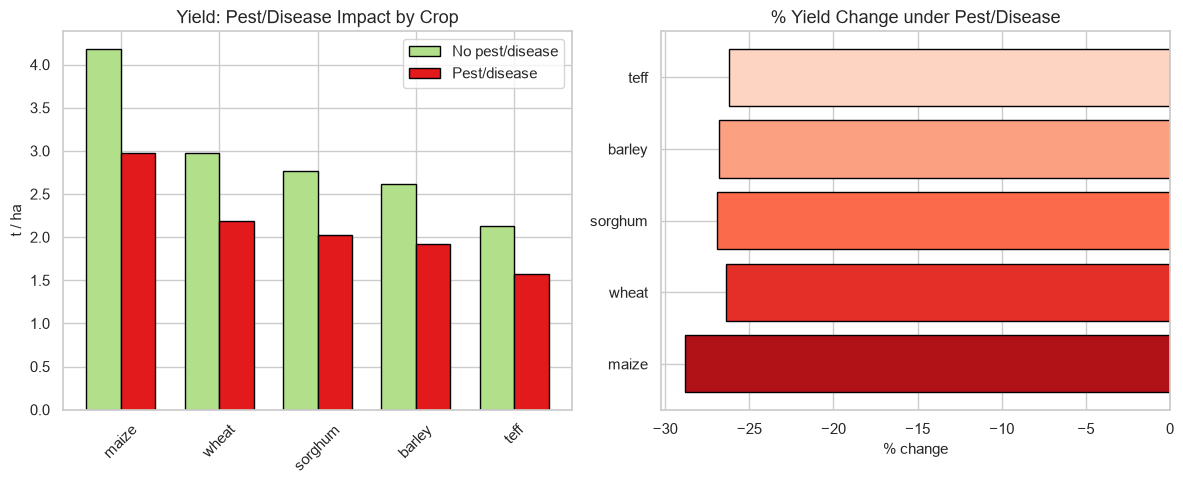

Hardest hit (absolute): maize (-1.204 t/ha)
Hardest hit (relative): maize (-28.8%)
Interpretation: Negative gaps indicate yield loss under pest/disease pressure. Crops with larger relative losses may need stronger integrated pest management.


In [23]:
# B2.5 Pest/disease yield gap by crop
pest_gap = (
    data.groupby(["crop_type", "pest_disease_flag"])["yield_tons_per_ha"]
    .mean()
    .unstack("pest_disease_flag")
    .rename(columns={0: "no_pest", 1: "pest"})
)
pest_gap["gap_tons"] = pest_gap["pest"] - pest_gap["no_pest"]
pest_gap["pct_change"] = (pest_gap["gap_tons"] / pest_gap["no_pest"] * 100).round(1)
pest_gap = pest_gap.sort_values("gap_tons").round(3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(pest_gap))
width = 0.35
axes[0].bar(x - width/2, pest_gap["no_pest"], width, label="No pest/disease", color="#b2df8a", edgecolor="black")
axes[0].bar(x + width/2, pest_gap["pest"], width, label="Pest/disease", color="#e31a1c", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(pest_gap.index, rotation=45)
axes[0].set_ylabel("t / ha")
axes[0].set_title("Yield: Pest/Disease Impact by Crop")
axes[0].legend()

axes[1].barh(pest_gap.index, pest_gap["pct_change"], color=sns.color_palette("Reds_r", len(pest_gap)), edgecolor="black")
axes[1].set_xlabel("% change")
axes[1].set_title("% Yield Change under Pest/Disease")
axes[1].axvline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

hardest_abs = pest_gap["gap_tons"].idxmin()
hardest_rel = pest_gap["pct_change"].idxmin()
print(f"Hardest hit (absolute): {hardest_abs} ({pest_gap.loc[hardest_abs, 'gap_tons']:.3f} t/ha)")
print(f"Hardest hit (relative): {hardest_rel} ({pest_gap.loc[hardest_rel, 'pct_change']:.1f}%)")
print(
    "Interpretation: Negative gaps indicate yield loss under pest/disease pressure. "
    "Crops with larger relative losses may need stronger integrated pest management."
)

## B3 — Agronomic Drivers

### B3.1 Fertilizer response

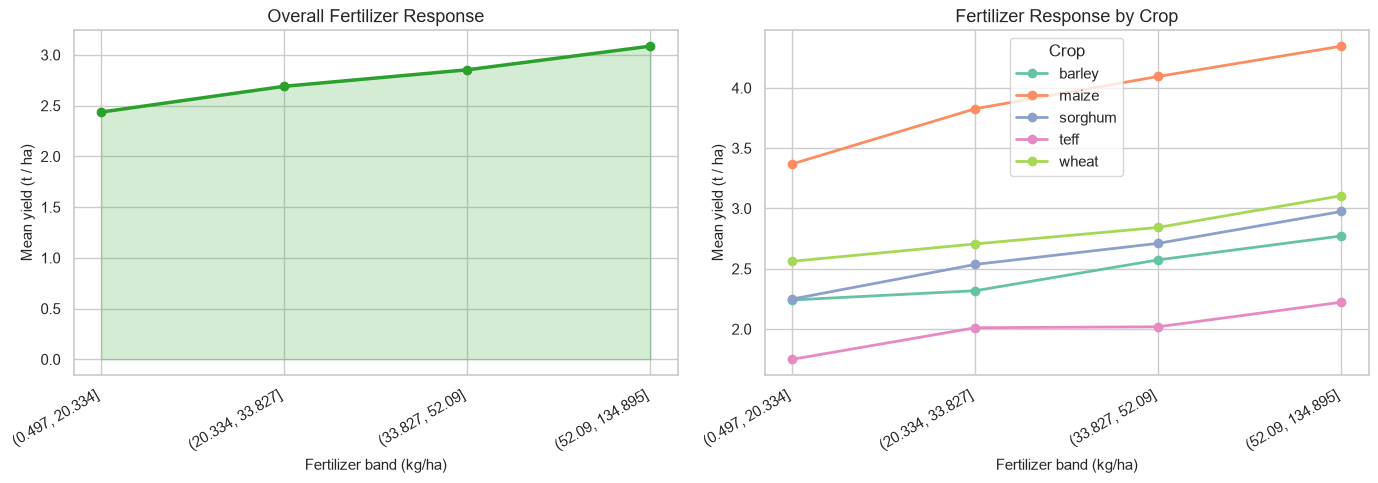

Overall response pattern: flattening (diminishing returns)
Interpretation: Mean yield moves from 2.44 to 3.09 t/ha across bands. Pattern appears flattening (diminishing returns).


In [24]:
# B3.1 Fertilizer response — 4 quartile bands
data["fertilizer_band"] = pd.qcut(
    data["fertilizer_kg_per_ha"], q=4, duplicates="drop"
)

fert_overall = (
    data.groupby("fertilizer_band", observed=True)["yield_tons_per_ha"]
    .agg(mean_yield="mean", plots="count")
    .reset_index()
)

fert_by_crop = pd.pivot_table(
    data, index="fertilizer_band", columns="crop_type",
    values="yield_tons_per_ha", aggfunc="mean", observed=True
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall response curve
band_labels = [str(b) for b in fert_overall["fertilizer_band"]]
axes[0].plot(range(len(fert_overall)), fert_overall["mean_yield"], marker="o", linewidth=2.5, color="#2ca02c")
axes[0].fill_between(range(len(fert_overall)), fert_overall["mean_yield"], alpha=0.2, color="#2ca02c")
axes[0].set_xticks(range(len(fert_overall)))
axes[0].set_xticklabels(band_labels, rotation=30, ha="right")
axes[0].set_title("Overall Fertilizer Response")
axes[0].set_ylabel("Mean yield (t / ha)")
axes[0].set_xlabel("Fertilizer band (kg/ha)")

# By crop
for crop in fert_by_crop.columns:
    axes[1].plot(range(len(fert_by_crop)), fert_by_crop[crop], marker="o", linewidth=2, label=crop)
axes[1].set_xticks(range(len(fert_by_crop)))
axes[1].set_xticklabels([str(b) for b in fert_by_crop.index], rotation=30, ha="right")
axes[1].set_title("Fertilizer Response by Crop")
axes[1].set_ylabel("Mean yield (t / ha)")
axes[1].set_xlabel("Fertilizer band (kg/ha)")
axes[1].legend(title="Crop")

plt.tight_layout()
plt.show()

means = fert_overall["mean_yield"].values
changes = np.diff(means) if len(means) >= 2 else []
if len(changes) >= 2:
    if all(c > 0 for c in changes) and changes[-1] < changes[0]:
        pattern = "flattening (diminishing returns)"
    elif all(c > 0 for c in changes):
        pattern = "roughly linear positive"
    elif all(abs(c) < 0.05 for c in changes):
        pattern = "flat"
    else:
        pattern = "mixed / non-monotonic"
else:
    pattern = "insufficient bands"
print(f"Overall response pattern: {pattern}")
print(
    f"Interpretation: Mean yield moves from {means[0]:.2f} to {means[-1]:.2f} t/ha across bands. "
    f"Pattern appears {pattern}."
)

### B3.2 Altitude by crop

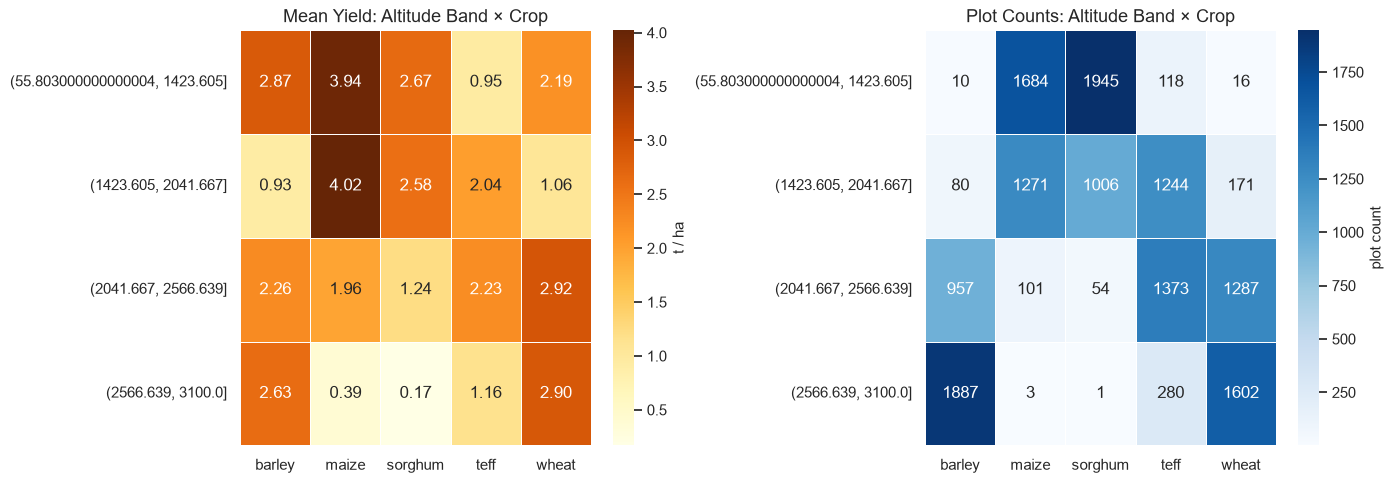

Cells with < 30 plots (treat with caution):
crop_type                       barley  maize  sorghum  wheat
altitude_band                                                
(55.803000000000004, 1423.605]    10.0    NaN      NaN   16.0
(2566.639, 3100.0]                 NaN    3.0      1.0    NaN
Best altitude band per crop:
  barley: (55.803000000000004, 1423.605]
  maize: (1423.605, 2041.667]
  sorghum: (55.803000000000004, 1423.605]
  teff: (2041.667, 2566.639]
  wheat: (2041.667, 2566.639]
Interpretation: Optimal altitude bands often differ by crop (cool-preferring cereals at higher elevations vs heat-tolerant sorghum lower down).


In [25]:
# B3.2 Altitude bands × crop
data["altitude_band"] = pd.qcut(data["altitude_m"], q=4, duplicates="drop")

alt_crop = pd.pivot_table(
    data, index="altitude_band", columns="crop_type",
    values="yield_tons_per_ha", aggfunc="mean", observed=True
).round(3)
alt_counts = pd.pivot_table(
    data, index="altitude_band", columns="crop_type",
    values="yield_tons_per_ha", aggfunc="count", observed=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of yields
sns.heatmap(alt_crop, annot=True, fmt=".2f", cmap="YlOrBr", ax=axes[0],
            linewidths=0.5, cbar_kws={"label": "t / ha"})
axes[0].set_title("Mean Yield: Altitude Band × Crop")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# Heatmap of plot counts (to flag sparse cells)
sns.heatmap(alt_counts, annot=True, fmt=".0f", cmap="Blues", ax=axes[1],
            linewidths=0.5, cbar_kws={"label": "plot count"})
axes[1].set_title("Plot Counts: Altitude Band × Crop")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

small = alt_counts < 30
if small.any().any():
    print("Cells with < 30 plots (treat with caution):")
    print(alt_counts.where(small).dropna(how="all").dropna(axis=1, how="all"))
else:
    print("No band×crop cell has fewer than 30 plots.")

best_band = alt_crop.idxmax()
print("Best altitude band per crop:")
for crop, band in best_band.items():
    print(f"  {crop}: {band}")
print(
    "Interpretation: Optimal altitude bands often differ by crop "
    "(cool-preferring cereals at higher elevations vs heat-tolerant sorghum lower down)."
)

### B3.3 Planting month

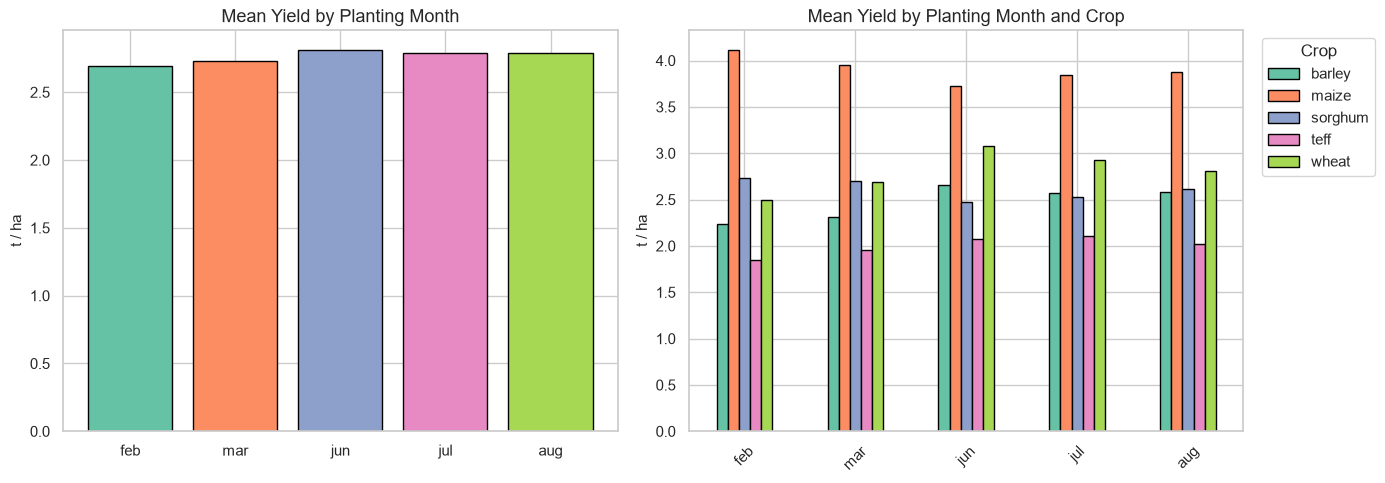

Planting-month effect (max−min): 0.119 t/ha
Region effect (max−min):         1.667 t/ha
Crop effect (max−min):           1.901 t/ha
Interpretation: Timing effect is 0.12 t/ha, smaller than the region effect and smaller than the crop effect.


In [26]:
# B3.3 Planting month
monthly = (
    data.groupby("planting_month")["yield_tons_per_ha"]
    .agg(mean_yield="mean", plots="count")
    .reset_index()
)
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
monthly["planting_month"] = pd.Categorical(
    monthly["planting_month"].astype(str).str.lower(),
    categories=[m for m in month_order if m in set(monthly["planting_month"].astype(str).str.lower())],
    ordered=True
)
monthly = monthly.sort_values("planting_month")

month_by_crop = pd.pivot_table(
    data, index="planting_month", columns="crop_type",
    values="yield_tons_per_ha", aggfunc="mean"
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly["planting_month"].astype(str), monthly["mean_yield"],
            color=sns.color_palette("Set2", len(monthly)), edgecolor="black")
axes[0].set_title("Mean Yield by Planting Month")
axes[0].set_ylabel("t / ha")
axes[0].set_xlabel("")

# Order month_by_crop index if possible
mbc = month_by_crop.copy()
mbc.index = pd.Categorical(mbc.index.astype(str).str.lower(),
    categories=[m for m in month_order if m in set(mbc.index.astype(str).str.lower())], ordered=True)
mbc = mbc.sort_index()
mbc.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Mean Yield by Planting Month and Crop")
axes[1].set_ylabel("t / ha")
axes[1].set_xlabel("")
axes[1].legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

month_effect = monthly["mean_yield"].max() - monthly["mean_yield"].min()
region_effect = yield_region["mean"].max() - yield_region["mean"].min()
crop_effect = yield_crop["mean"].max() - yield_crop["mean"].min()
print(f"Planting-month effect (max−min): {month_effect:.3f} t/ha")
print(f"Region effect (max−min):         {region_effect:.3f} t/ha")
print(f"Crop effect (max−min):           {crop_effect:.3f} t/ha")
print(
    f"Interpretation: Timing effect is {month_effect:.2f} t/ha, "
    f"{'smaller than' if month_effect < region_effect else 'comparable to or larger than'} the region effect "
    f"and {'smaller than' if month_effect < crop_effect else 'comparable to or larger than'} the crop effect."
)

### B3.4 Distance to market

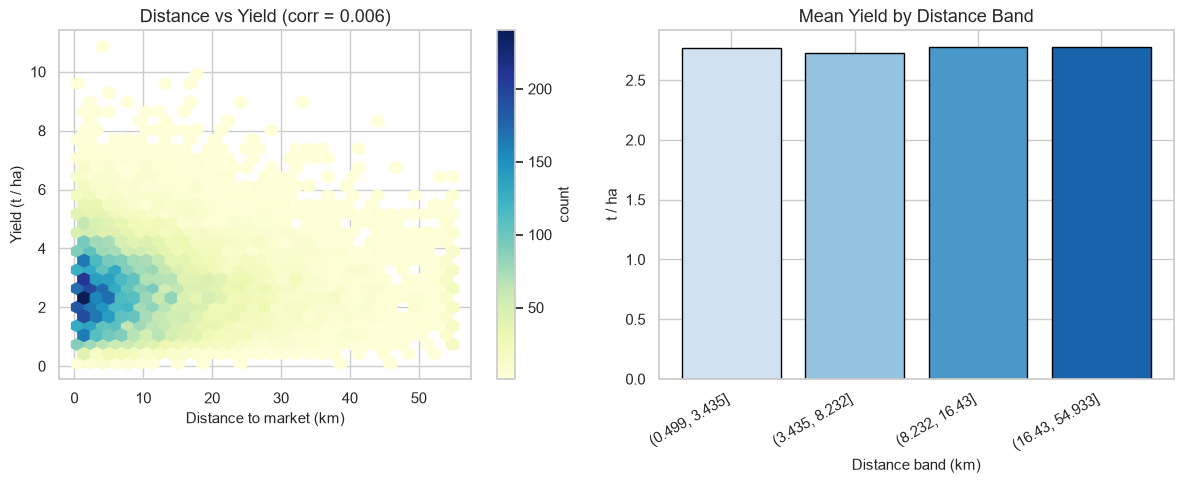

Pearson correlation (distance vs yield): 0.006
Interpretation: Correlation is 0.006. Weak association — keep as a secondary feature if it helps in models, but do not expect large gains.


In [27]:
# B3.4 Distance to market vs yield
distance_corr = data["distance_to_market_km"].corr(data["yield_tons_per_ha"])

data["market_distance_band"] = pd.qcut(
    data["distance_to_market_km"], q=4, duplicates="drop"
)
dist_yield = (
    data.groupby("market_distance_band", observed=True)["yield_tons_per_ha"]
    .agg(mean_yield="mean", plots="count")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter with lowess-style trend (hexbin for density)
hb = axes[0].hexbin(data["distance_to_market_km"], data["yield_tons_per_ha"],
                    gridsize=30, cmap="YlGnBu", mincnt=1)
axes[0].set_title(f"Distance vs Yield (corr = {distance_corr:.3f})")
axes[0].set_xlabel("Distance to market (km)")
axes[0].set_ylabel("Yield (t / ha)")
plt.colorbar(hb, ax=axes[0], label="count")

# Binned means
band_labels = [str(b) for b in dist_yield["market_distance_band"]]
axes[1].bar(range(len(dist_yield)), dist_yield["mean_yield"],
            color=sns.color_palette("Blues", len(dist_yield)), edgecolor="black")
axes[1].set_xticks(range(len(dist_yield)))
axes[1].set_xticklabels(band_labels, rotation=30, ha="right")
axes[1].set_title("Mean Yield by Distance Band")
axes[1].set_ylabel("t / ha")
axes[1].set_xlabel("Distance band (km)")

plt.tight_layout()
plt.show()

print(f"Pearson correlation (distance vs yield): {distance_corr:.3f}")
print(
    f"Interpretation: Correlation is {distance_corr:.3f}. "
    f"{'Weak association — keep as a secondary feature if it helps in models, but do not expect large gains.' if abs(distance_corr) < 0.15 else 'Moderate association — worth retaining as a model feature.' if abs(distance_corr) < 0.3 else 'Notable association — retain as a model feature.'}"
)

## B4 — Time & Weather

### B4.1 Yield trend 2021–2024

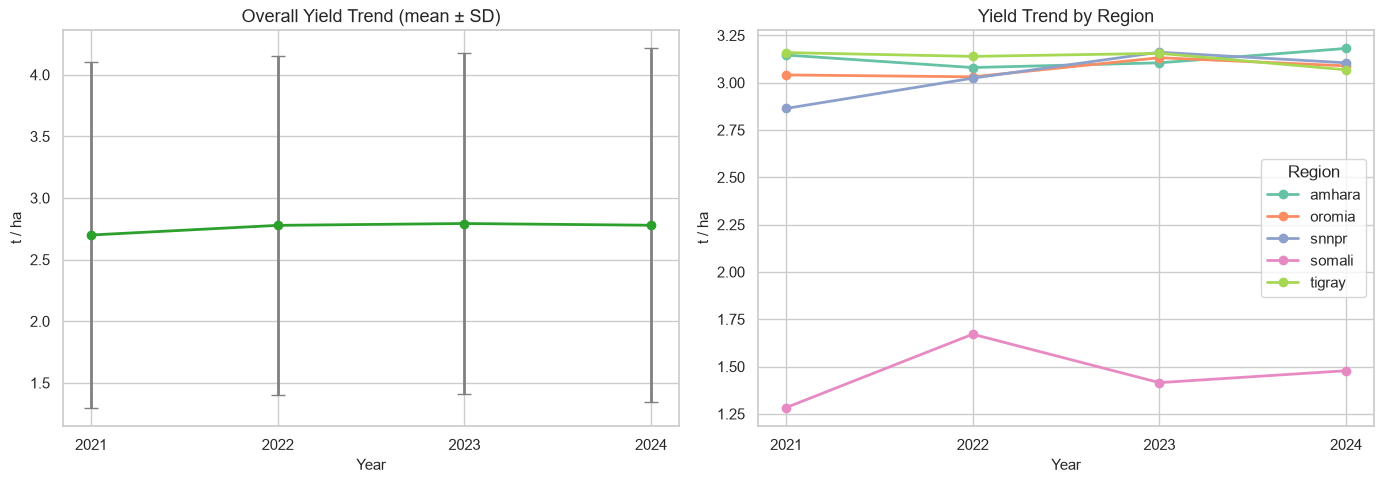

Year-to-year |Δ mean| : [0.078, 0.015, 0.014]
Overall yield std     : 1.400
Interpretation: Year-to-year changes are small relative to the overall spread — the series mostly bounces around with no strong trend.


In [28]:
# B4.1 Yield by year (overall and by region)
yield_year = (
    data.groupby("survey_year")["yield_tons_per_ha"]
    .agg(mean_yield="mean", std_yield="std", plots="count")
    .reset_index()
)

yield_year_region = pd.pivot_table(
    data, index="survey_year", columns="region",
    values="yield_tons_per_ha", aggfunc="mean"
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall trend with error bars
axes[0].errorbar(yield_year["survey_year"], yield_year["mean_yield"],
                 yerr=yield_year["std_yield"], marker="o", linewidth=2,
                 color="#2ca02c", capsize=5, ecolor="gray")
axes[0].set_title("Overall Yield Trend (mean ± SD)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("t / ha")
axes[0].set_xticks(yield_year["survey_year"])

# By region
for region in yield_year_region.columns:
    axes[1].plot(yield_year_region.index, yield_year_region[region],
                 marker="o", linewidth=2, label=region)
axes[1].set_title("Yield Trend by Region")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("t / ha")
axes[1].legend(title="Region")
axes[1].set_xticks(yield_year_region.index)

plt.tight_layout()
plt.show()

yoy = yield_year["mean_yield"].diff().dropna().abs()
typical_spread = data["yield_tons_per_ha"].std()
print(f"Year-to-year |Δ mean| : {yoy.round(3).tolist()}")
print(f"Overall yield std     : {typical_spread:.3f}")
print(
    f"Interpretation: Year-to-year changes "
    f"{'are small relative to the overall spread — the series mostly bounces around with no strong trend.' if yoy.max() < 0.25 * typical_spread else 'are noticeable relative to the spread — a real multi-year movement may be present.'}"
)

### B4.2 Weather anomalies

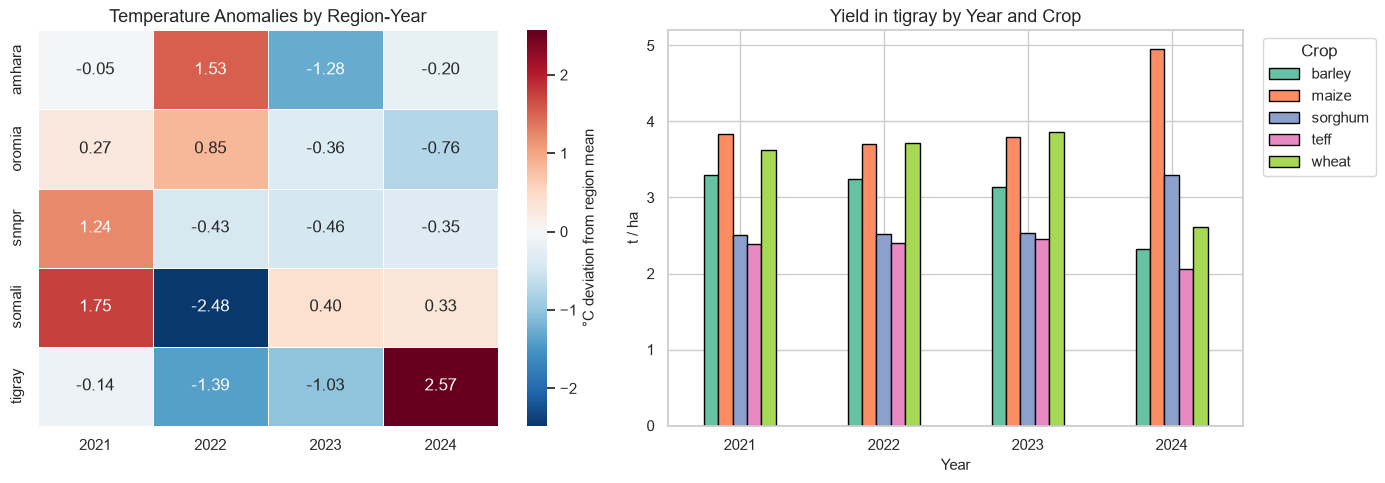

Most unusual region-year: tigray, 2024 (deviation 2.57 °C)

Mean yield in that region by year:
 survey_year  mean_yield  plots
        2021       3.159    794
        2022       3.139    765
        2023       3.155    784
        2024       3.068    747

Interpretation: tigray in 2024 is the most unusual temperature year. Compare the yield bars for that year against other years above; crop-specific series show whether the effect is uniform.


In [29]:
# B4.2 Region-year temperature anomalies
temp_col = "season_temp_mean"
if temp_col not in data.columns:
    for c in data.columns:
        if "temp" in c.lower() and "mean" in c.lower():
            temp_col = c
            break

region_year_temp = (
    data.groupby(["region", "survey_year"])[temp_col]
    .mean()
    .reset_index(name="season_temp")
)
region_avg = region_year_temp.groupby("region")["season_temp"].transform("mean")
region_year_temp["temp_deviation"] = region_year_temp["season_temp"] - region_avg

idx = region_year_temp["temp_deviation"].abs().idxmax()
unusual_region = region_year_temp.loc[idx, "region"]
unusual_year = region_year_temp.loc[idx, "survey_year"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of temperature deviations
temp_pivot = region_year_temp.pivot(index="region", columns="survey_year", values="temp_deviation")
sns.heatmap(temp_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0],
            linewidths=0.5, cbar_kws={"label": "°C deviation from region mean"})
axes[0].set_title("Temperature Anomalies by Region-Year")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# Yield in the unusual region across years, by crop
sub = data[data["region"] == unusual_region]
crop_cmp = (
    sub.groupby(["survey_year", "crop_type"])["yield_tons_per_ha"]
    .mean()
    .unstack("crop_type")
)
crop_cmp.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title(f"Yield in {unusual_region} by Year and Crop")
axes[1].set_ylabel("t / ha")
axes[1].set_xlabel("Year")
axes[1].legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Most unusual region-year: {unusual_region}, {int(unusual_year)} "
      f"(deviation {region_year_temp.loc[idx, 'temp_deviation']:.2f} °C)")

reg_year_yield = (
    sub.groupby("survey_year")["yield_tons_per_ha"]
    .agg(mean_yield="mean", plots="count")
    .reset_index()
)
print("\nMean yield in that region by year:")
print(reg_year_yield.round(3).to_string(index=False))
print(
    f"\nInterpretation: {unusual_region} in {int(unusual_year)} is the most unusual temperature year. "
    "Compare the yield bars for that year against other years above; "
    "crop-specific series show whether the effect is uniform."
)

### B4.3 Plot-reported vs station rainfall

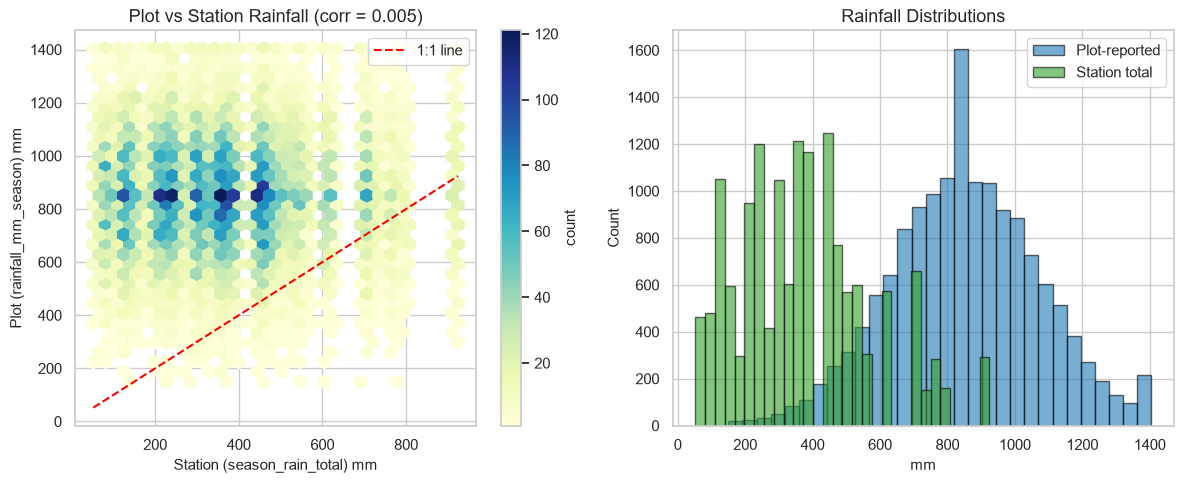

Station column used: season_rain_total
Correlation:              0.005
Mean absolute difference: 496.7 mm
Typical plot rainfall:    851.2 mm
Typical station total:    370.1 mm
Interpretation: Agreement is weak. Plot self-reports and station aggregates capture different spatial/temporal scales; both can still be useful as complementary features.


In [30]:
# B4.3 Plot-reported rainfall vs weather-station seasonal total
rain_station = "season_rain_total"
rain_plot = "rainfall_mm_season"

if rain_station not in data.columns:
    for c in data.columns:
        if "rain" in c.lower() and ("total" in c.lower() or "season" in c.lower()) and c != rain_plot:
            rain_station = c
            break

valid = data[[rain_plot, rain_station]].dropna()
corr = valid[rain_plot].corr(valid[rain_station])
mad = (valid[rain_plot] - valid[rain_station]).abs().mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter / hexbin
hb = axes[0].hexbin(valid[rain_station], valid[rain_plot], gridsize=30, cmap="YlGnBu", mincnt=1)
axes[0].plot([valid[rain_station].min(), valid[rain_station].max()],
             [valid[rain_station].min(), valid[rain_station].max()],
             "r--", linewidth=1.5, label="1:1 line")
axes[0].set_title(f"Plot vs Station Rainfall (corr = {corr:.3f})")
axes[0].set_xlabel(f"Station ({rain_station}) mm")
axes[0].set_ylabel(f"Plot ({rain_plot}) mm")
axes[0].legend()
plt.colorbar(hb, ax=axes[0], label="count")

# Distribution comparison
axes[1].hist(valid[rain_plot], bins=30, alpha=0.6, label="Plot-reported", color="#1f78b4", edgecolor="black")
axes[1].hist(valid[rain_station], bins=30, alpha=0.6, label="Station total", color="#33a02c", edgecolor="black")
axes[1].set_title("Rainfall Distributions")
axes[1].set_xlabel("mm")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Station column used: {rain_station}")
print(f"Correlation:              {corr:.3f}")
print(f"Mean absolute difference: {mad:.1f} mm")
print(f"Typical plot rainfall:    {valid[rain_plot].mean():.1f} mm")
print(f"Typical station total:    {valid[rain_station].mean():.1f} mm")
print(
    "Interpretation: "
    + (
        "The two series are moderately aligned; residual differences likely reflect "
        "local microclimate, different season definitions, and farmer recall error."
        if corr >= 0.3 else
        "Agreement is weak. Plot self-reports and station aggregates capture different "
        "spatial/temporal scales; both can still be useful as complementary features."
    )
)

## Summary

All 14 analysis tasks (B1.1–B4.3) are answered above with **charts** and short interpretations.
Re-run this notebook after `01_cleaning_and_integration.ipynb` has produced `data/processed/master_train.csv`.